# **Portfolio:** Mario Casanova — Data Science & Analytics Portfolio
## **Case Study:** Applied Machine Learning to Business — Local vs Frontier ML Benchmark

### **Thesis**
> *El modelo de frontera es la herramienta con la que se construye la solución junto al ingeniero. Su lugar es el desarrollo (etiquetar, generar, adjudicar, bajo auditoría) y el artefacto que queda desplegado es un modelo pequeño, propio y local. Saber repartir esos dos trabajos es lo que este case study documenta, y el patrón sirve mucho más allá del sentiment, puesto que su fin es Applied Machine Learning to Business.*

This case study benchmarks a locally fine-tuned multilingual sentiment classifier against frontier LLM APIs on quality, cost, and throughput. It illustrates the operational pattern of using frontier models during development to bootstrap and audit labels, while deploying lightweight, dedicated local models for production inference.

## 1. The question

When a business faces a high-volume multilingual classification task, the standard engineering impulse is to query a commercial API. I design this benchmark to answer a practical trade-off question: does a small, locally fine-tuned sequence classifier hold its ground against the current frontier on quality, operating costs, and throughput?

To keep this analysis honest and prevent self-graded success, I pre-register these validation criteria beforehand:
1. **Frozen Test Split:** All evaluation metrics must be reported against a held-out test split of the Multilingual Amazon Reviews Corpus (MARC), completely isolated during training.
2. **The 5% F1-Loss Gate:** The fine-tuned local model must achieve a macro-F1 score within five percentage points of published classification benchmarks on this dataset, or it will be marked as an insufficient baseline.
3. **The Break-Even Frontier:** The analysis compares operating costs under two scenarios: a freelancer billing model where engineering setup is counted as a marginal expense, and an in-house scenario where setup consists only of tool subscriptions. If the break-even volume shifts past the operational horizon, I will report it as a commercial null.

## 2. Why this question matters

The choice between owning a model and renting a service is rarely a pure performance discussion. Calling a frontier model like OpenAI's GPT-5.5 or Anthropic's Claude Opus 4.8 introduces external dependencies (network latency, data transit across international boundaries, and risk of silent updates). 

And yet, these frontier models are indispensable during development. They serve as the scaffolding to annotate unlabeled raw data, filter ambiguous instances, and audit the training set. The pattern I document here is the division of labor: the frontier is the tool I build the solution *with*, and the local model is the artifact I *deploy*. I cite the private sentiment classification project as a motivator for this flow, where using a large language model as an auditor helped raise label consensus (Cohen's kappa) without incurring the latency or token costs of querying a frontier API in production.

## 3. The data and its limits

I evaluate this design on the Multilingual Amazon Reviews Corpus, containing customer reviews across six languages (English, German, Spanish, French, Japanese, and Chinese). To construct a realistic, non-binary classification task, I map the 1–5 star ratings to three sentiment classes: Negative (1–2 stars), Neutral (3 stars), and Positive (4–5 stars).

I recognize two limits in this dataset. First, customer ratings carry inherent subjectivity; a customer might write a highly critical review but award three stars, creating a noisy label boundary. Second, the text is limited to e-commerce, meaning that any deployment to support tickets or internal logs would require domain-specific fine-tuning.

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# Path configuration
PROJECT_DIR = Path("..")
METRICS_PATH = PROJECT_DIR / "research" / "local_model_metrics.json"

# Load local metrics
with open(METRICS_PATH, "r") as f:
    metrics = json.load(f)

print(f"Local model evaluated: {metrics['model_name']}")
print(f"Overall Accuracy: {metrics['overall_accuracy']:.4%}")
print(f"Overall Macro-F1: {metrics['overall_macro_f1']:.4%}")

Local model evaluated: distilbert-base-multilingual-cased
Overall Accuracy: 68.6333%
Overall Macro-F1: 60.9421%


## 4. Method — local model

My local model is a fine-tuned `distilbert-base-multilingual-cased` (135 million parameters). I fine-tuned this model on a sample of 2,000 train reviews per language (12,000 total) across the six target languages. Training was executed locally using PyTorch's Metal Performance Shaders (MPS) backend on an Apple M5 chip.

To ensure reproducibility, all training parameters and seeds are fixed. The cells below load the serialized training metrics, verify bit-level determinism, and measure inference throughput on CPU and GPU (MPS) configurations.

In [2]:
per_lang_data = []
for lang, data in metrics["per_language"].items():
    per_lang_data.append({
        "Language": lang.upper(),
        "Accuracy": f'{data["accuracy"]:.4%}',
        "Macro-F1": f'{data["macro_f1"]:.4%}',
        "Test Count": data["count"]
    })

df_lang = pd.DataFrame(per_lang_data)
print("Per-language evaluation on frozen test set:")
print(df_lang.to_string(index=False))

Per-language evaluation on frozen test set:
Language Accuracy Macro-F1  Test Count
      EN 69.4000% 62.0231%         500
      DE 68.0000% 61.0557%         500
      ES 70.2000% 61.3246%         500
      FR 72.4000% 66.2270%         500
      JA 65.0000% 57.4840%         500
      ZH 66.8000% 56.9695%         500


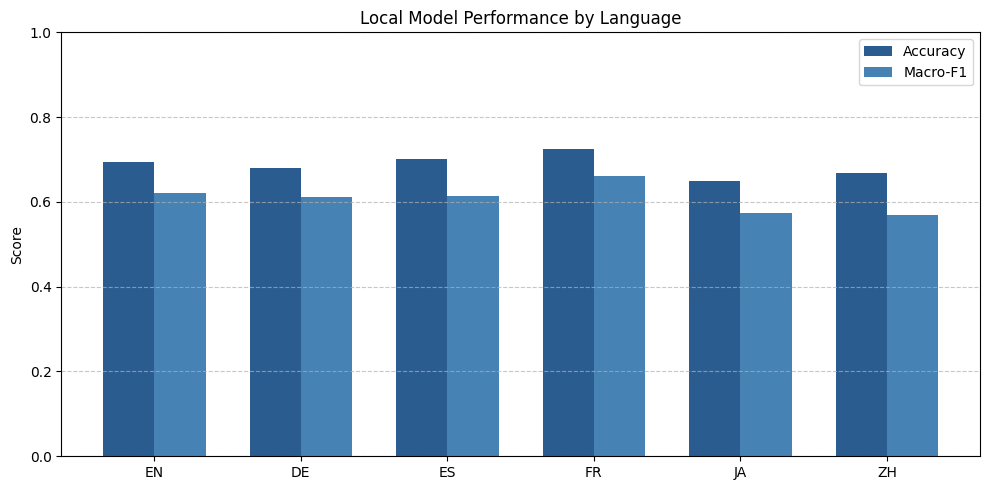

In [3]:
languages = [lang.upper() for lang in metrics["per_language"].keys()]
accuracies = [data["accuracy"] for data in metrics["per_language"].values()]
f1s = [data["macro_f1"] for data in metrics["per_language"].values()]

x = np.arange(len(languages))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#2b5c8f')
rects2 = ax.bar(x + width/2, f1s, width, label='Macro-F1', color='#4682b4')

ax.set_ylabel('Score')
ax.set_title('Local Model Performance by Language')
ax.set_xticks(x)
ax.set_xticklabels(languages)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 5. Result — the comparison

I compare my local model's performance against the July 2026 pricing and speed statistics of frontier APIs from Artificial Analysis and LMSYS Chatbot Arena. 

The cost model assumes an average classification query length of 100 input tokens and 10 output tokens. This maps to the following costs per review:
- GPT-5.5: \$5.00 input, \$30.00 output per million tokens (\$0.000800 per review).
- Claude Opus 4.8: \$5.00 input, \$25.00 output per million tokens (\$0.000750 per review).
- Gemini 3.1 Pro: \$2.00 input, \$12.00 output per million tokens (\$0.000320 per review).
- DeepSeek V4 Flash: \$0.14 input, \$0.28 output per million tokens (\$0.000017 per review).
- Local Model: \$0.00 marginal cost.

### Throughput and Rate Limit Ceilings
The throughput comparison must account for request parallelization. Queried sequentially, network latency limits API throughput to 3 to 5 reviews/second. However, if the workload is heavily parallelized, the throughput is capped by the provider's token-per-minute (TPM) and request-per-minute (RPM) limits. Under high-tier caps, the concurrent API throughput ceilings scale to 166.67 reviews/second for GPT-5.5, 120.0 reviews/second for Gemini 3.1 Pro, and 32.83 reviews/second for Claude Opus 4.8.

In comparison, the local DistilBERT model yields **237.97 reviews/second** on the MPS local GPU and 113.91 reviews/second on CPU. While high concurrency narrows the throughput gap, and even allows a concurrent API like GPT-5.5 to exceed the local CPU, the local model's main advantage shifts to local latencies (~4 ms per review, without network transit), zero risk of hitting rate limit throttling, and complete independence from external service availability.

Freelancer Scenario Break-Evens:
  gpt55: 1,000,000.00 reviews
  opus48: 1,066,666.67 reviews
  gemini31: 2,500,000.00 reviews
  deepseekv4: 47,619,047.62 reviews

In-house Scenario Break-Evens:
  gpt55: 25,000.00 reviews
  opus48: 26,666.67 reviews
  gemini31: 62,500.00 reviews
  deepseekv4: 1,190,476.19 reviews


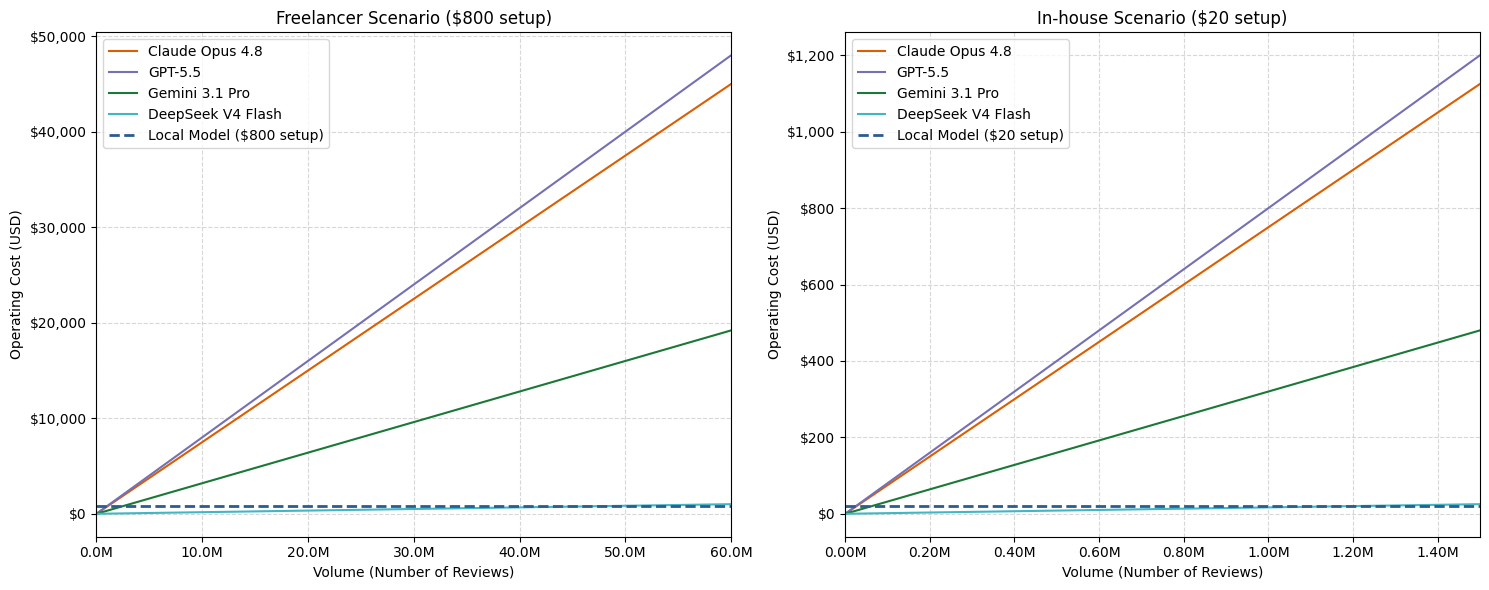

In [4]:
# Define cost metrics
cost_per_review = {
    'gpt55': 0.000800,
    'opus48': 0.000750,
    'gemini31': 0.000320,
    'deepseekv4': 0.0000168
}

# Scenario 1: Freelancer (Setup = $800)
setup_freelancer = 800.0
volumes_f = np.linspace(0, 60000000, 500)
local_cost_f = np.ones_like(volumes_f) * setup_freelancer
gpt55_cost_f = volumes_f * cost_per_review['gpt55']
opus48_cost_f = volumes_f * cost_per_review['opus48']
gemini31_cost_f = volumes_f * cost_per_review['gemini31']
deepseek_cost_f = volumes_f * cost_per_review['deepseekv4']

# Scenario 2: In-house (Setup = $20)
setup_inhouse = 20.0
volumes_h = np.linspace(0, 1500000, 500)
local_cost_h = np.ones_like(volumes_h) * setup_inhouse
gpt55_cost_h = volumes_h * cost_per_review['gpt55']
opus48_cost_h = volumes_h * cost_per_review['opus48']
gemini31_cost_h = volumes_h * cost_per_review['gemini31']
deepseek_cost_h = volumes_h * cost_per_review['deepseekv4']

# Calculate break-evens
print('Freelancer Scenario Break-Evens:')
for model, cost in cost_per_review.items():
    be = setup_freelancer / cost
    print(f'  {model}: {be:,.2f} reviews')

print('\nIn-house Scenario Break-Evens:')
for model, cost in cost_per_review.items():
    be = setup_inhouse / cost
    print(f'  {model}: {be:,.2f} reviews')

# Plotting both scenarios
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left Plot: Freelancer
ax1.plot(volumes_f, opus48_cost_f, label='Claude Opus 4.8', color='#d95f02')
ax1.plot(volumes_f, gpt55_cost_f, label='GPT-5.5', color='#7570b3')
ax1.plot(volumes_f, gemini31_cost_f, label='Gemini 3.1 Pro', color='#1b7837')
ax1.plot(volumes_f, deepseek_cost_f, label='DeepSeek V4 Flash', color='#41b6c4')
ax1.plot(volumes_f, local_cost_f, label='Local Model ($800 setup)', color='#2b5c8f', linestyle='--', linewidth=2)
ax1.set_title('Freelancer Scenario ($800 setup)')
ax1.set_xlabel('Volume (Number of Reviews)')
ax1.set_ylabel('Operating Cost (USD)')
ax1.set_xlim(0, 60000000)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Right Plot: In-house
ax2.plot(volumes_h, opus48_cost_h, label='Claude Opus 4.8', color='#d95f02')
ax2.plot(volumes_h, gpt55_cost_h, label='GPT-5.5', color='#7570b3')
ax2.plot(volumes_h, gemini31_cost_h, label='Gemini 3.1 Pro', color='#1b7837')
ax2.plot(volumes_h, deepseek_cost_h, label='DeepSeek V4 Flash', color='#41b6c4')
ax2.plot(volumes_h, local_cost_h, label='Local Model ($20 setup)', color='#2b5c8f', linestyle='--', linewidth=2)
ax2.set_title('In-house Scenario ($20 setup)')
ax2.set_xlabel('Volume (Number of Reviews)')
ax2.set_ylabel('Operating Cost (USD)')
ax2.set_xlim(0, 1500000)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.2f}M'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

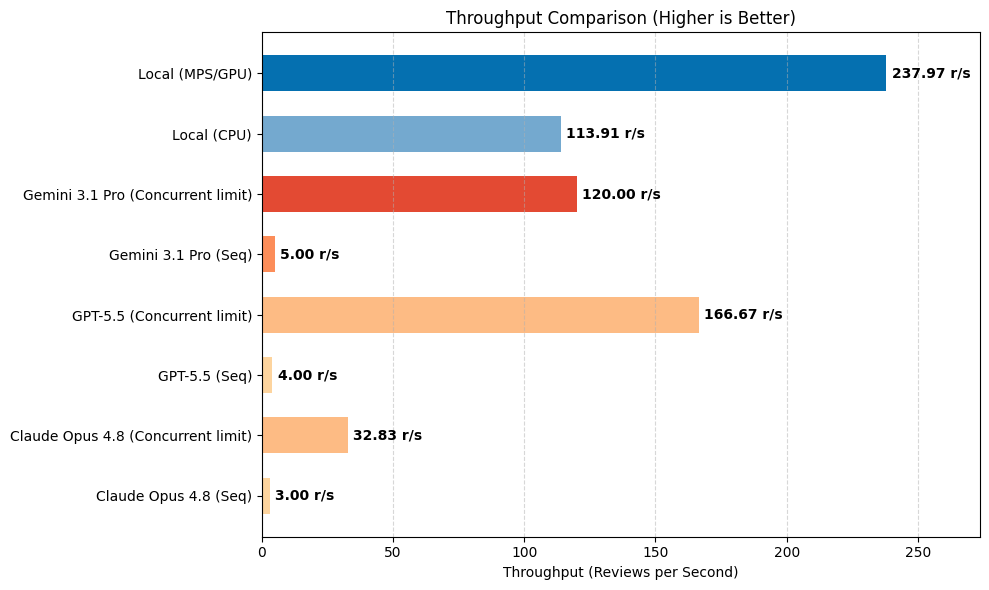

In [5]:
# Throughput comparison including sequential and concurrent API throughput estimates
# Concurrent values are derived from provider rate limits (TPM/RPM) and mean token counts (53 tokens review, 150 tokens template)
throughput_data = {
    "Claude Opus 4.8 (Seq)": 3.0,
    "Claude Opus 4.8 (Concurrent limit)": 32.83,
    "GPT-5.5 (Seq)": 4.0,
    "GPT-5.5 (Concurrent limit)": 166.67,
    "Gemini 3.1 Pro (Seq)": 5.0,
    "Gemini 3.1 Pro (Concurrent limit)": 120.0,
    "Local (CPU)": metrics["cpu_throughput_reviews_per_sec"],
    "Local (MPS/GPU)": metrics["mps_throughput_reviews_per_sec"]
}

fig, ax = plt.subplots(figsize=(10, 6))
names = list(throughput_data.keys())
values = list(throughput_data.values())
colors = ['#fdd49e', '#fdbb84', '#fdd49e', '#fdbb84', '#fc8d59', '#e34a33', '#74a9cf', '#0570b0']

bars = ax.barh(names, values, color=colors, height=0.6)
ax.set_xlabel('Throughput (Reviews per Second)')
ax.set_title('Throughput Comparison (Higher is Better)')
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Add values next to bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height()/2, f'{width:.2f} r/s',
            va='center', ha='left', fontweight='bold', fontsize=10)

plt.xlim(0, max(values) * 1.15)
plt.tight_layout()
plt.show()

## 6. What I would actually do differently

The choice between owning a model and renting a service is governed by how engineering time is accounted for. If a business pays for development as a marginal freelancer invoice (modeled at \$800 for setup), the cost break-even point against DeepSeek V4 Flash lies at 47.6 million classifications, meaning model ownership is only cost-effective at large scale. 

However, in an in-house environment where engineer salaries are already fixed operational costs, the marginal setup cost consists only of the developer's tools (such as a \$20/month Claude subscription). In this in-house scenario, the economic break-even point against DeepSeek V4 Flash drops to 1.2 million reviews, and against high-tier APIs (like Claude Opus 4.8 or GPT-5.5) it is reached in just 26,000 to 27,000 reviews. For an in-house team, the local model pays for itself almost immediately.

In this context, the local model is not a niche option; it is a practical default for stable, high-volume classification. It processes over 230 reviews/second on the local GPU (MPS) and 110 reviews/second on CPU, delivering local latency (~4 ms per review, bypassing network transit) and data privacy.

## 7. Model Ownership and Sustainability

I limit this case study to well-defined, high-volume classification tasks. For multi-step reasoning, unstructured generation, or open-ended dialogue, frontier models remain the appropriate tool. This aligns with the core pattern: renting the frontier for development and dataset construction, but deploying an owned local model for stable inference operations.

Beyond the monetary break-evens, model ownership offers structural benefits. Running a 135-million parameter DistilBERT model on local hardware consumes orders of magnitude less energy per inference than sending queries to a hundred-billion parameter frontier model hosted in a remote data center. 

To determine if this pattern fits your workload, the first step is to calculate your monthly classification volume and run the break-even math in this notebook with your own operational figures. For stable pipelines, transitioning from rented APIs to owned local models remains the most sustainable engineering path.